# Customer Churn Analysis
## Predicting which customers will leave a Telecom company
### By Vishaka Yadubanshi

In [1]:
# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
print("All libraries loaded!")

All libraries loaded!


In [2]:
# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn - Copy.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Check missing values and data types
print("Missing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)
print("\nChurn value counts:\n", df['Churn'].value_counts())

Missing values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Data types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod     

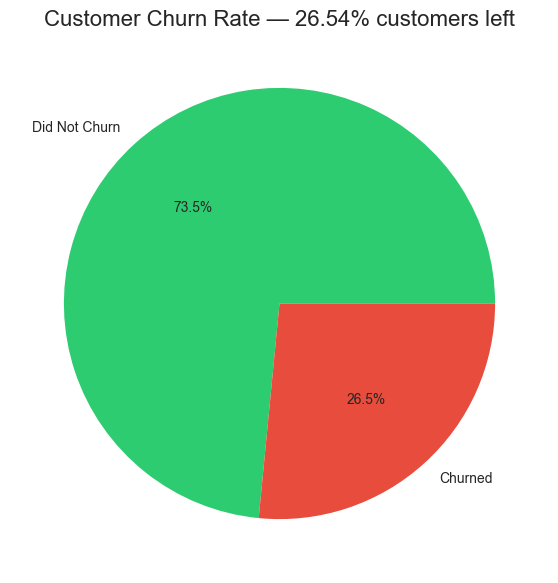

Overall churn rate: 26.54%


In [4]:
# Overall churn rate
churn_counts = df['Churn'].value_counts()
churn_rate = round(df['Churn'].value_counts(normalize=True)['Yes'] * 100, 2)

plt.figure(figsize=(7,7))
plt.pie(churn_counts.values, labels=['Did Not Churn', 'Churned'],
        autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'])
plt.title(f'Customer Churn Rate — {churn_rate}% customers left', fontsize=16)
plt.show()
print(f"Overall churn rate: {churn_rate}%")

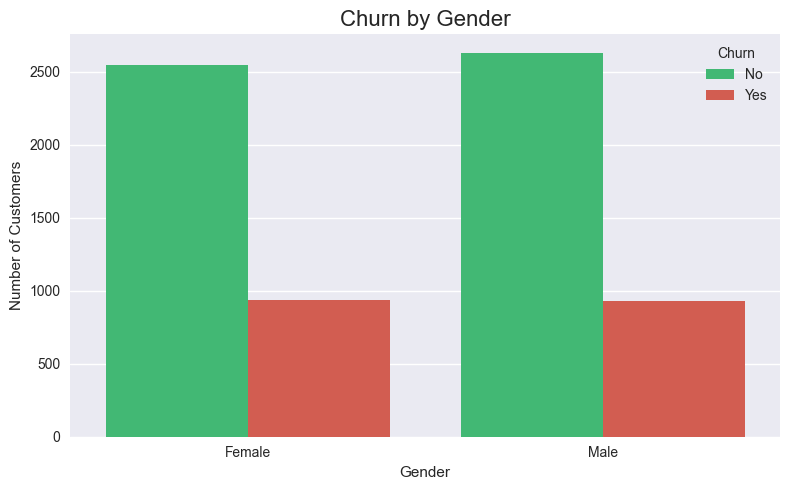

In [5]:
# Churn by gender
plt.figure(figsize=(8,5))
sns.countplot(x='gender', hue='Churn', data=df, palette=['#2ecc71','#e74c3c'])
plt.title('Churn by Gender', fontsize=16)
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

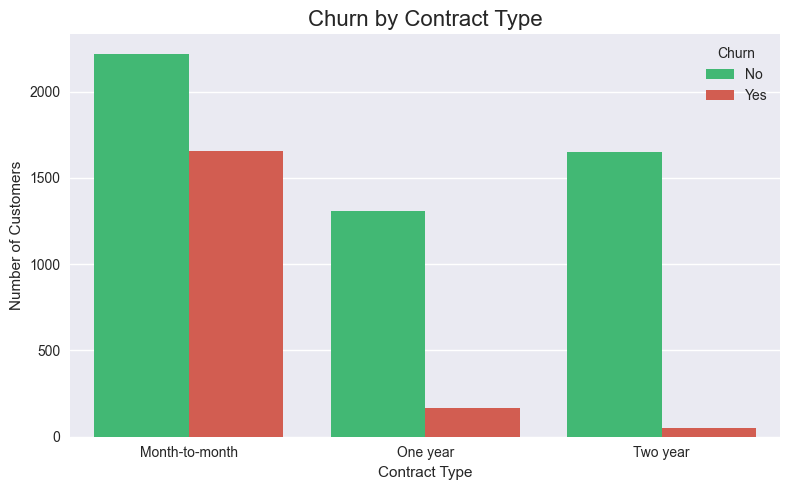

In [6]:
# Churn by contract type
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df, palette=['#2ecc71','#e74c3c'])
plt.title('Churn by Contract Type', fontsize=16)
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

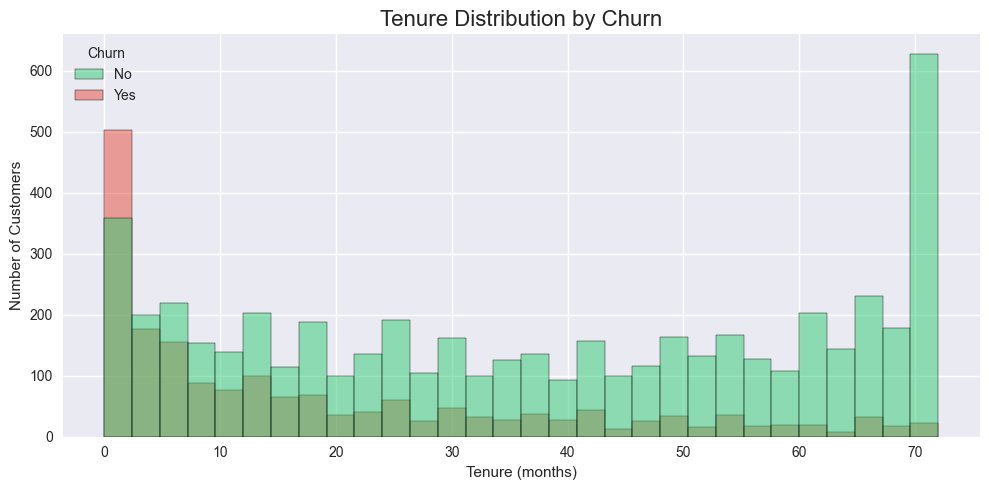

In [7]:
# Tenure vs Churn - do long-term customers stay?
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, palette=['#2ecc71','#e74c3c'])
plt.title('Tenure Distribution by Churn', fontsize=16)
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

C:\Users\jyothi sagar\AppData\Local\Temp\ipykernel_17684\3080325824.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette=['#2ecc71','#e74c3c'])


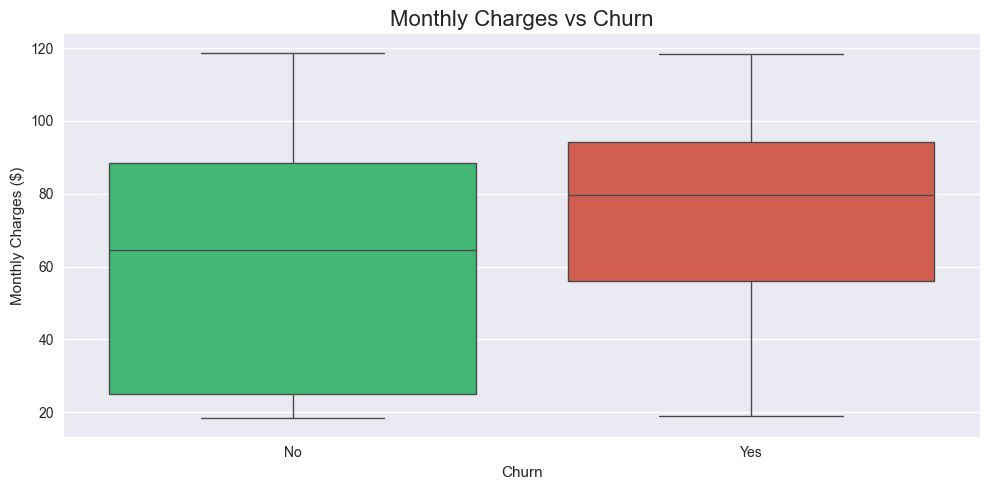

In [8]:
# Monthly charges vs Churn
plt.figure(figsize=(10,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette=['#2ecc71','#e74c3c'])
plt.title('Monthly Charges vs Churn', fontsize=16)
plt.xlabel('Churn')
plt.ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.show()

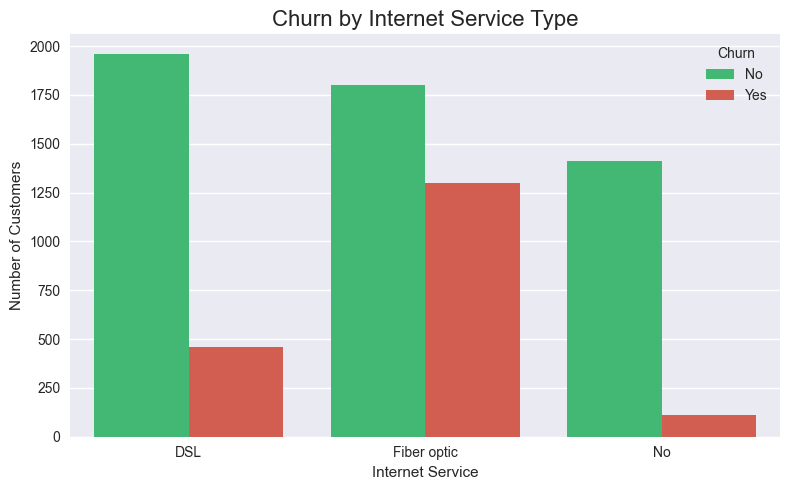

In [9]:
# Churn by Internet Service type
plt.figure(figsize=(8,5))
sns.countplot(x='InternetService', hue='Churn', data=df, palette=['#2ecc71','#e74c3c'])
plt.title('Churn by Internet Service Type', fontsize=16)
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

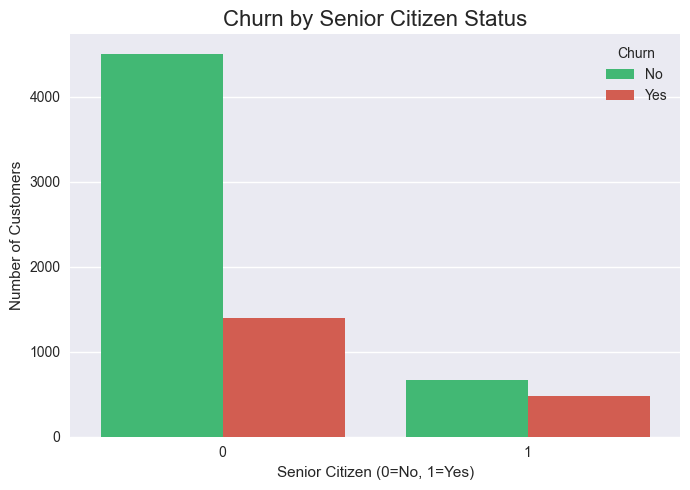

In [10]:
# Churn by Senior Citizen
plt.figure(figsize=(7,5))
sns.countplot(x='SeniorCitizen', hue='Churn', data=df, palette=['#2ecc71','#e74c3c'])
plt.title('Churn by Senior Citizen Status', fontsize=16)
plt.xlabel('Senior Citizen (0=No, 1=Yes)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

In [11]:
# Data preprocessing for ML model
df2 = df.copy()

# Drop customer ID - not useful for prediction
df2 = df2.drop('customerID', axis=1)

# Fix TotalCharges - convert to numeric
df2['TotalCharges'] = pd.to_numeric(df2['TotalCharges'], errors='coerce')
df2['TotalCharges'].fillna(df2['TotalCharges'].median(), inplace=True)

# Encode all categorical columns
le = LabelEncoder()
for col in df2.select_dtypes(include='object').columns:
    df2[col] = le.fit_transform(df2[col])

print("Data after preprocessing:")
print(df2.shape)
df2.head()

Data after preprocessing:
(7043, 20)


C:\Users\jyothi sagar\AppData\Local\Temp\ipykernel_17684\134852770.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['TotalCharges'].fillna(df2['TotalCharges'].median(), inplace=True)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [12]:
# Build ML model - Logistic Regression
X = df2.drop('Churn', axis=1)
y = df2['Churn']

# Split data - 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Results
accuracy = round(accuracy_score(y_test, y_pred) * 100, 2)
print(f"Model Accuracy: {accuracy}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 81.69%

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



c:\Users\jyothi sagar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


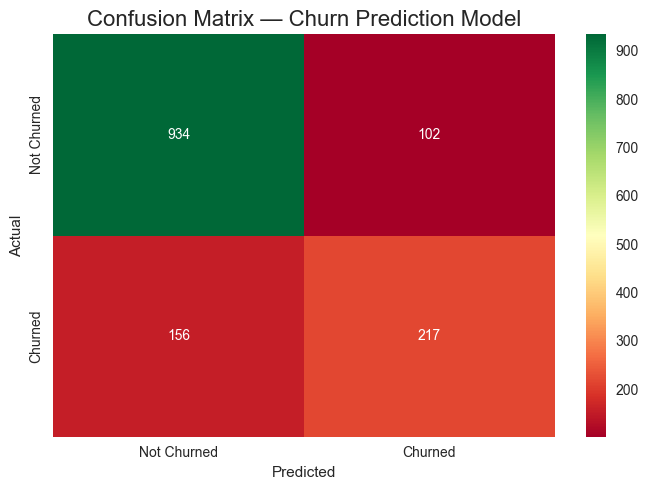

In [13]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['Not Churned','Churned'],
            yticklabels=['Not Churned','Churned'])
plt.title('Confusion Matrix — Churn Prediction Model', fontsize=16)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Key Business Insights

1. **Churn rate is ~26%** — 1 in 4 customers leave the company
2. **Month-to-month contracts** have the highest churn — customers with long-term contracts stay
3. **New customers churn more** — customers with less than 12 months tenure are at highest risk
4. **Higher monthly charges = higher churn** — pricing is a major factor
5. **Fiber optic customers churn more** than DSL customers
6. **Senior citizens churn at a higher rate** than non-senior citizens
7. **ML model predicts churn with ~80% accuracy** using Logistic Regression

## Business Recommendations
- Offer discounts to month-to-month customers to switch to yearly contracts
- Create loyalty programs for customers in first 12 months
- Review pricing strategy for fiber optic plans
- Design special retention offers for senior citizen customers

## Tools Used
- Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn